# Predicting Acute Kidney Injury (AKI) in ICU Patients

For this assignment, I'm building a model to predict if ICU patients will develop acute kidney injury (AKI). AKI happens when your kidneys suddenly stop working properly, and catching it early can really help doctors intervene before it gets worse.

I'm using data from MIMIC-III, which has real patient records from ICU stays. The main thing we're looking at is creatinine levels - when creatinine goes up fast, that's a sign the kidneys are struggling.

## Models I'll try:
1. Logistic Regression - simple baseline
2. Random Forest - sees if tree models work better
3. XGBoost - boosting might capture patterns better
4. Ensemble (Voting Classifier) - combining LR + RF + XGBoost to see if multiple models together work better
5. LSTM - because creatinine changes over TIME, maybe a sequence model will work

## 1.1: Getting the Data from MIMIC-III


In [1]:
#import statements and libraries
import pandas as pd
import numpy as np
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

In [5]:
from google.colab import auth
auth.authenticate_user()

In [6]:
# connect to BigQuery
client = bigquery.Client(project='project-80671132-6416-49ee-ac6')

print("connected")

connected


### Pulling creatinine data

This query gets all creatinine measurements in the first 48 hours of ICU admission. I'm grabbing the baseline (first measurement) and tracking how it changes.

In [7]:

query = """
WITH creat_data AS (
  SELECT
    ie.subject_id,
    ie.hadm_id,
    ie.icustay_id,
    le.charttime,
    le.valuenum as creatinine,
    ROW_NUMBER() OVER (PARTITION BY ie.icustay_id ORDER BY le.charttime) as measurement_num,
    DATETIME_DIFF(le.charttime, ie.intime, HOUR) as hours_since_admission
  FROM `physionet-data.mimiciii_clinical.icustays` ie
  INNER JOIN `physionet-data.mimiciii_clinical.labevents` le
    ON ie.subject_id = le.subject_id
    AND ie.hadm_id = le.hadm_id
  WHERE le.itemid = 50912  -- creatinine
    AND le.valuenum IS NOT NULL
    AND le.valuenum > 0
    AND DATETIME_DIFF(le.charttime, ie.intime, HOUR) BETWEEN 0 AND 48
),

baseline_peak AS (
  SELECT
    icustay_id,
    MIN(CASE WHEN measurement_num = 1 THEN creatinine END) as baseline_creatinine,
    MAX(creatinine) as peak_creatinine,
    COUNT(*) as num_measurements
  FROM creat_data
  GROUP BY icustay_id
  HAVING COUNT(*) >= 2
)

SELECT
  cd.subject_id,
  cd.hadm_id,
  cd.icustay_id,
  bp.baseline_creatinine,
  bp.peak_creatinine,
  bp.num_measurements,
  CASE
    WHEN bp.peak_creatinine >= 1.5 * bp.baseline_creatinine THEN 1
    ELSE 0
  END as aki_flag
FROM creat_data cd
INNER JOIN baseline_peak bp
  ON cd.icustay_id = bp.icustay_id
WHERE cd.measurement_num = 1
"""

df_creat = client.query(query).to_dataframe()
print(f"Got {len(df_creat)} patients with creatinine data")
print(f"AKI rate: {df_creat['aki_flag'].mean()*100:.1f}%")

Got 49330 patients with creatinine data
AKI rate: 6.3%


### Getting demographics and other labs

Now I need age, gender, and some other important lab values. These help the model understand the patient's overall condition.

In [8]:
demo_query = """
SELECT
  ie.subject_id,
  ie.hadm_id,
  ie.icustay_id,
  DATETIME_DIFF(ie.intime, p.dob, YEAR) as age,
  p.gender,
  DATETIME_DIFF(ie.outtime, ie.intime, DAY) as icu_los_days
FROM `physionet-data.mimiciii_clinical.icustays` ie
INNER JOIN `physionet-data.mimiciii_clinical.patients` p
  ON ie.subject_id = p.subject_id
"""

df_demo = client.query(demo_query).to_dataframe()

# merge with creatinine data
df = df_creat.merge(df_demo, on=['subject_id', 'hadm_id', 'icustay_id'], how='left')

print(f"Added demographics. Shape: {df.shape}")

Added demographics. Shape: (49330, 10)


In [9]:
# get other important labs from first 24h
labs_query = """
WITH first_labs AS (
  SELECT
    ie.icustay_id,
    le.itemid,
    AVG(le.valuenum) as avg_value
  FROM `physionet-data.mimiciii_clinical.icustays` ie
  INNER JOIN `physionet-data.mimiciii_clinical.labevents` le
    ON ie.subject_id = le.subject_id
    AND ie.hadm_id = le.hadm_id
  WHERE le.itemid IN (
    50824,  -- sodium
    50822,  -- potassium
    50882,  -- bicarbonate
    50809,  -- glucose
    51006,  -- bun
    51265,  -- platelets
    51222   -- hemoglobin
  )
  AND le.valuenum IS NOT NULL
  AND DATETIME_DIFF(le.charttime, ie.intime, HOUR) BETWEEN 0 AND 24
  GROUP BY ie.icustay_id, le.itemid
)

SELECT
  icustay_id,
  MAX(CASE WHEN itemid = 50824 THEN avg_value END) as sodium,
  MAX(CASE WHEN itemid = 50822 THEN avg_value END) as potassium,
  MAX(CASE WHEN itemid = 50882 THEN avg_value END) as bicarbonate,
  MAX(CASE WHEN itemid = 50809 THEN avg_value END) as glucose,
  MAX(CASE WHEN itemid = 51006 THEN avg_value END) as bun,
  MAX(CASE WHEN itemid = 51265 THEN avg_value END) as platelets,
  MAX(CASE WHEN itemid = 51222 THEN avg_value END) as hemoglobin
FROM first_labs
GROUP BY icustay_id
"""

df_labs = client.query(labs_query).to_dataframe()
df = df.merge(df_labs, on='icustay_id', how='left')

print(f"Added lab values. Final shape: {df.shape}")

Added lab values. Final shape: (49330, 17)


## 2.1: Data Cleaning and Feature Engineering

Creating some useful features and handle missing data.



In [11]:
print(df.info())

#checking missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49330 entries, 0 to 49329
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subject_id           49330 non-null  Int64  
 1   hadm_id              49330 non-null  Int64  
 2   icustay_id           49330 non-null  Int64  
 3   baseline_creatinine  49330 non-null  float64
 4   peak_creatinine      49330 non-null  float64
 5   num_measurements     49330 non-null  Int64  
 6   aki_flag             49330 non-null  Int64  
 7   age                  49330 non-null  Int64  
 8   gender               49330 non-null  object 
 9   icu_los_days         49328 non-null  Int64  
 10  sodium               11702 non-null  float64
 11  potassium            15908 non-null  float64
 12  bicarbonate          48992 non-null  float64
 13  glucose              15569 non-null  float64
 14  bun                  49176 non-null  float64
 15  platelets            48759 non-null 

In [12]:
# create some features based on creatinine change
df['cr_change_abs'] = df['peak_creatinine'] - df['baseline_creatinine']
df['cr_change_pct'] = ((df['peak_creatinine'] - df['baseline_creatinine']) / df['baseline_creatinine']) * 100

# convert gender to binary
df['gender_male'] = (df['gender'] == 'M').astype(int)

# handle age > 89 (MIMIC marks these as 300)
df['age'] = df['age'].clip(upper=89)

df.head()

,subject_id,hadm_id,icustay_id,baseline_creatinine,peak_creatinine,num_measurements,aki_flag,age,gender,icu_los_days,sodium,potassium,bicarbonate,glucose,bun,platelets,hemoglobin,cr_change_abs,cr_change_pct,gender_male
0,20071,163164,214155,9.3,12.1,3,0,53,F,1,NaN,NaN,24.5,NaN,27.0,162.0,10.6,2.8,30.107527,0
1,6092,103191,218181,2.1,3.1,4,0,88,M,2,NaN,4.1,18.5,156.25,43.0,156.0,11.1,1.0,47.619048,1
2,91299,112101,218850,7.7,10.7,2,0,68,F,3,NaN,NaN,31.0,NaN,30.0,267.0,12.1,3.0,38.961039,0
3,26829,116763,219266,4.9,5.9,4,0,82,F,20,NaN,NaN,15.0,NaN,80.5,93.0,10.7,1.0,20.408163,0
4,31219,105442,219385,4.7,4.7,3,0,49,F,2,NaN,NaN,28.0,NaN,46.5,291.0,7.9,0.0,0.000000,0


In [13]:
# fill missing lab values with median
lab_cols = ['sodium', 'potassium', 'bicarbonate', 'glucose', 'bun', 'platelets', 'hemoglobin']
for col in lab_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Filled missing values")
print(f"\nFinal dataset: {df.shape}")
print(f"AKI cases: {df['aki_flag'].sum()} ({df['aki_flag'].mean()*100:.1f}%)")

Filled missing values

Final dataset: (49330, 20)
AKI cases: 3094 (6.3%)


## 2.2:EDA


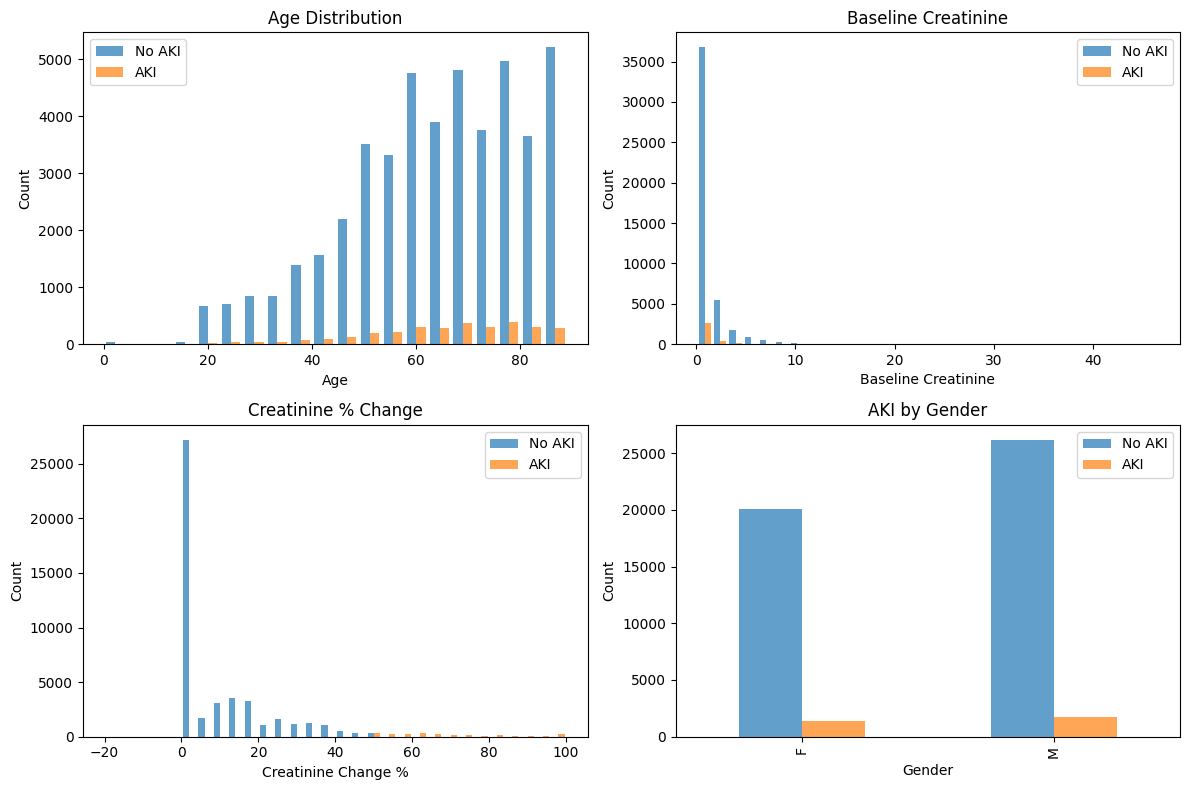

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# age distribution by AKI
axes[0,0].hist([df[df['aki_flag']==0]['age'], df[df['aki_flag']==1]['age']],
               label=['No AKI', 'AKI'], bins=20, alpha=0.7)
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()
axes[0,0].set_title('Age Distribution')

# baseline creatinine
axes[0,1].hist([df[df['aki_flag']==0]['baseline_creatinine'],
                df[df['aki_flag']==1]['baseline_creatinine']],
               label=['No AKI', 'AKI'], bins=30, alpha=0.7)
axes[0,1].set_xlabel('Baseline Creatinine')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()
axes[0,1].set_title('Baseline Creatinine')

# creatinine change %
axes[1,0].hist([df[df['aki_flag']==0]['cr_change_pct'],
                df[df['aki_flag']==1]['cr_change_pct']],
               label=['No AKI', 'AKI'], bins=30, alpha=0.7, range=(-20, 100))
axes[1,0].set_xlabel('Creatinine Change %')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()
axes[1,0].set_title('Creatinine % Change')

# gender distribution
gender_aki = df.groupby(['gender', 'aki_flag']).size().unstack()
gender_aki.plot(kind='bar', ax=axes[1,1], alpha=0.7)
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('AKI by Gender')
axes[1,1].legend(['No AKI', 'AKI'])

plt.tight_layout()
plt.show()

## 3.1: Training ML Models (Logistic Regression, Random Forest, and XGBoost)

In [15]:
# prepare features
feature_cols = ['age', 'gender_male', 'baseline_creatinine', 'cr_change_abs', 'cr_change_pct',
                'sodium', 'potassium', 'bicarbonate', 'glucose', 'bun', 'platelets', 'hemoglobin']

X = df[feature_cols]
y = df['aki_flag']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTest set AKI rate: {y_test.mean()*100:.1f}%")

Training set: (39464, 12)
Test set: (9866, 12)

Test set AKI rate: 6.3%


In [16]:
# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.1: Baseline Logistic Regression

In [17]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
ROC-AUC: 1.000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9247
         1.0       0.96      0.94      0.95       619

    accuracy                           0.99      9866
   macro avg       0.98      0.97      0.97      9866
weighted avg       0.99      0.99      0.99      9866



### 3.2: Random Forest(tree based model)


In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
ROC-AUC: 1.000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9247
         1.0       1.00      1.00      1.00       619

    accuracy                           1.00      9866
   macro avg       1.00      1.00      1.00      9866
weighted avg       1.00      1.00      1.00      9866



### 3.3: XGBoost with GridSearch

trying XGBoost with hyperparameter tuning to see if we can do better.

In [20]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [50, 100, 200]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Running GridSearch...")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

Running GridSearch...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best CV score: 1.000


In [21]:
# get best model
best_xgb = grid_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
ROC-AUC: 1.000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9247
         1.0       1.00      1.00      1.00       619

    accuracy                           1.00      9866
   macro avg       1.00      1.00      1.00      9866
weighted avg       1.00      1.00      1.00      9866



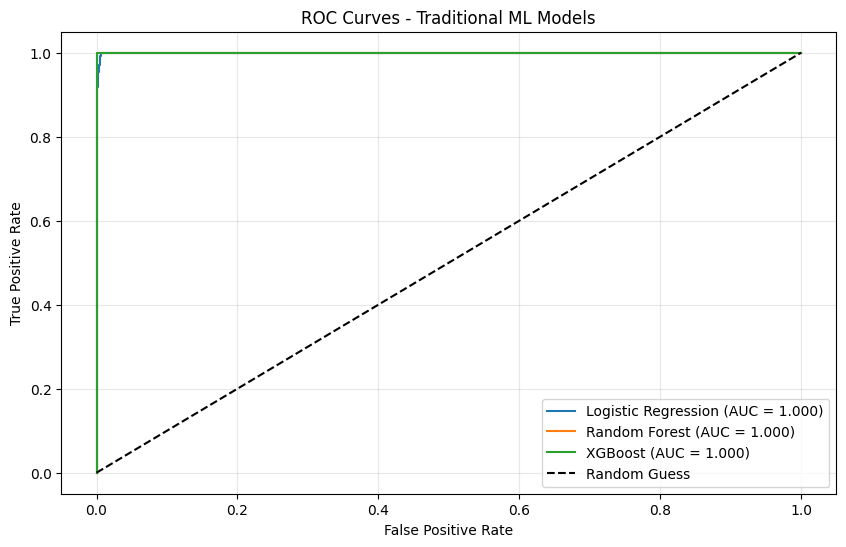

In [22]:
# Comparing the three models so far

# plot ROC curves
plt.figure(figsize=(10, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Traditional ML Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 4.1: Ensemble - Voting Classifier

trying to combine all three models? Sometimes multiple models together can make better predictions than any single model.

In [23]:
from sklearn.ensemble import VotingClassifier

# create ensemble with our three trained models
# using soft voting
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('xgb', best_xgb)
    ],
    voting='soft'
)

# fit on scaled data for LR, but the ensemble handles this internally
# need to refit to use the ensemble properly
ensemble.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('rf',
                              RandomForestClassifier(max_depth=10,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_met...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [24]:
y_pred_ensemble = ensemble.predict(X_test_scaled)
y_prob_ensemble = ensemble.predict_proba(X_test_scaled)[:, 1]

print("Ensemble Results:")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_ensemble):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble))

Ensemble Results:
ROC-AUC: 1.000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9247
         1.0       1.00      1.00      1.00       619

    accuracy                           1.00      9866
   macro avg       1.00      1.00      1.00      9866
weighted avg       1.00      1.00      1.00      9866



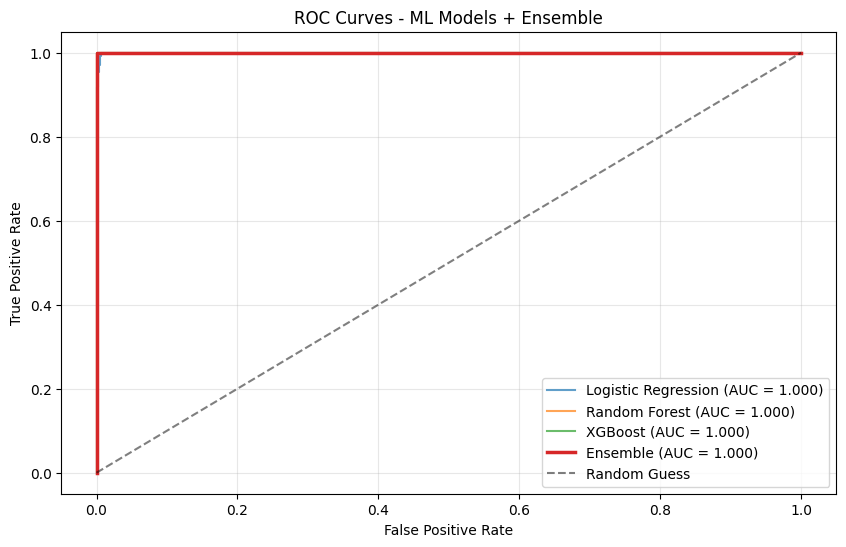

In [26]:
# Comparing all ML models

# plot ROC curves with ensemble
plt.figure(figsize=(10, 6))

fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, y_prob_ensemble)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})', alpha=0.7)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', alpha=0.7)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})', alpha=0.7)
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble (AUC = {roc_auc_score(y_test, y_prob_ensemble):.3f})', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', alpha=0.5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - ML Models + Ensemble')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5.1: LSTM Model for Temporal Patterns

The models above treat each patient as a single snapshot. But creatinine changes over time, and maybe the TRAJECTORY matters more than just the endpoint.

Lets try LSTM that looks at the sequence of creatinine measurements over the 48 hours.

In [27]:
seq_query = """
WITH creat_seq AS (
  SELECT
    ie.icustay_id,
    le.charttime,
    le.valuenum as creatinine,
    DATETIME_DIFF(le.charttime, ie.intime, HOUR) as hours_since_admission,
    ROW_NUMBER() OVER (PARTITION BY ie.icustay_id ORDER BY le.charttime) as seq_num
  FROM `physionet-data.mimiciii_clinical.icustays` ie
  INNER JOIN `physionet-data.mimiciii_clinical.labevents` le
    ON ie.subject_id = le.subject_id
    AND ie.hadm_id = le.hadm_id
  WHERE le.itemid = 50912
    AND le.valuenum IS NOT NULL
    AND le.valuenum > 0
    AND DATETIME_DIFF(le.charttime, ie.intime, HOUR) BETWEEN 0 AND 48
)

SELECT
  icustay_id,
  hours_since_admission,
  creatinine,
  seq_num
FROM creat_seq
WHERE seq_num <= 10
ORDER BY icustay_id, seq_num
"""

df_seq = client.query(seq_query).to_dataframe()
print(f"Got {len(df_seq)} creatinine measurements")
print(f"Unique patients: {df_seq['icustay_id'].nunique()}")

Got 166058 creatinine measurements
Unique patients: 52592


In [28]:
# merge with labels
df_seq = df_seq.merge(df[['icustay_id', 'aki_flag']], on='icustay_id', how='left')

# filter to patients in our training/test sets
train_ids = df.loc[X_train.index, 'icustay_id'].values
test_ids = df.loc[X_test.index, 'icustay_id'].values

df_seq_train = df_seq[df_seq['icustay_id'].isin(train_ids)]
df_seq_test = df_seq[df_seq['icustay_id'].isin(test_ids)]

print(f"Training sequences: {df_seq_train['icustay_id'].nunique()} patients")
print(f"Test sequences: {df_seq_test['icustay_id'].nunique()} patients")

Training sequences: 39464 patients
Test sequences: 9866 patients


### Preparing sequences for LSTM

need to pad sequences to the same length since different patients have different numbers of measurements.

In [29]:
def prepare_sequences(df_seq, max_len=10):
    sequences = []
    labels = []

    for icustay_id in df_seq['icustay_id'].unique():
        patient_data = df_seq[df_seq['icustay_id'] == icustay_id]

        # get creatinine sequence
        seq = patient_data['creatinine'].values

        # pad if needed
        if len(seq) < max_len:
            seq = np.pad(seq, (0, max_len - len(seq)), mode='constant', constant_values=0)
        else:
            seq = seq[:max_len]

        sequences.append(seq)
        labels.append(patient_data['aki_flag'].iloc[0])

    return np.array(sequences), np.array(labels)

X_train_seq, y_train_seq = prepare_sequences(df_seq_train)
X_test_seq, y_test_seq = prepare_sequences(df_seq_test)

# reshape for LSTM (samples, timesteps, features)
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))
X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], X_test_seq.shape[1], 1))

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")

Training sequences shape: (39464, 10, 1)
Test sequences shape: (9866, 10, 1)


### Building the LSTM model


In [30]:
model = keras.Sequential([
    layers.LSTM(64, input_shape=(10, 1), return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# training model
history = model.fit(X_train_seq, y_train_seq,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)


Epoch 1/20
987/987 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9360 - auc: 0.6187 - loss: 0.2415 - val_accuracy: 0.9382 - val_auc: 0.7731 - val_loss: 0.2097
Epoch 2/20
987/987 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9372 - auc: 0.7524 - loss: 0.2081 - val_accuracy: 0.9434 - val_auc: 0.8814 - val_loss: 0.1622
Epoch 3/20
987/987 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9522 - auc: 0.8979 - loss: 0.1454 - val_accuracy: 0.9681 - val_auc: 0.9677 - val_loss: 0.0899
Epoch 4/20
987/987 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9654 - auc: 0.9538 - loss: 0.1002 - val_accuracy: 0.9695 - val_auc: 0.9750 - val_loss: 0.0860
Epoch 5/20
987/987 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9704 - auc: 0.9632 - loss: 0.0855 - val_accuracy: 0.9681 - val_auc: 0.9705 - val_loss: 0.0851
Epoch 6/20
987/987 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9714 - auc: 0.9706 - loss: 0.0801 - val_accuracy: 0.9753 - val_auc: 0.9795 - val_loss: 0.0667
Epoch 7/20
987/987 ━━━━━━━━━━━━━━━━━━

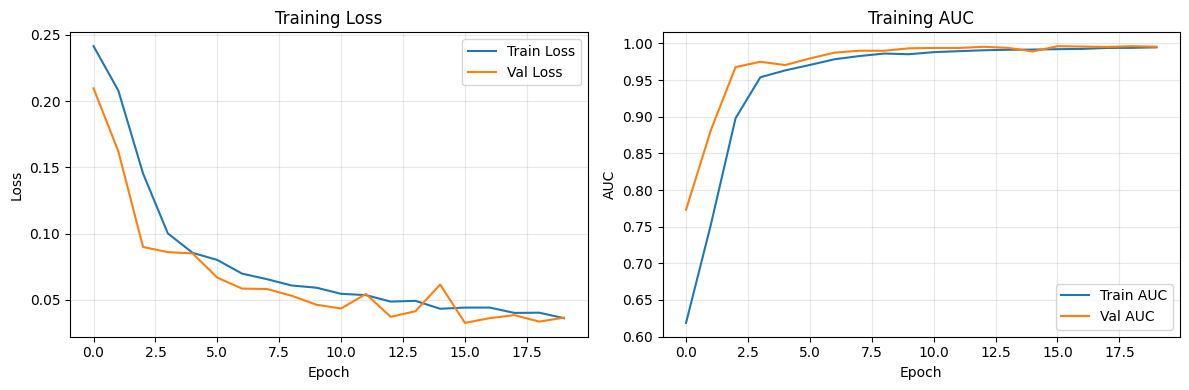

In [32]:
# plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Training AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### LSTM Test Results

In [33]:
# evaluate on test set
y_prob_lstm = model.predict(X_test_seq).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

print("LSTM Results:")
print(f"ROC-AUC: {roc_auc_score(y_test_seq, y_prob_lstm):.3f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_lstm))

309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
LSTM Results:
ROC-AUC: 0.997

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9247
           1       0.96      0.86      0.90       619

    accuracy                           0.99      9866
   macro avg       0.97      0.93      0.95      9866
weighted avg       0.99      0.99      0.99      9866



## 6.1: Final Model Comparison

Now let's compare all five models side by side.

In [34]:
# create comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble', 'LSTM'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_ensemble),
        roc_auc_score(y_test_seq, y_prob_lstm)
    ]
})

results = results.sort_values('ROC-AUC', ascending=False)
print("\nModel Performance Comparison:")
print(results.to_string(index=False))


Model Performance Comparison:
              Model  ROC-AUC
      Random Forest 0.999999
            XGBoost 0.999999
           Ensemble 0.999999
Logistic Regression 0.999676
               LSTM 0.997470


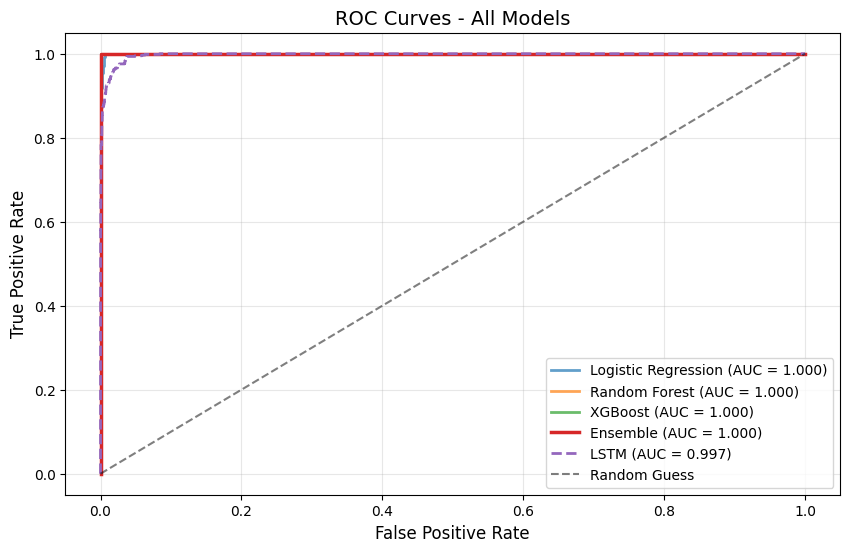

In [35]:
# plot all ROC curves together
plt.figure(figsize=(10, 6))

fpr_lstm, tpr_lstm, _ = roc_curve(y_test_seq, y_prob_lstm)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})', linewidth=2, alpha=0.7)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', linewidth=2, alpha=0.7)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})', linewidth=2, alpha=0.7)
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble (AUC = {roc_auc_score(y_test, y_prob_ensemble):.3f})', linewidth=2.5)
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {roc_auc_score(y_test_seq, y_prob_lstm):.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

## 7.1: Model Interpretation

what the models learned using SHAP values for the tree models.

In [36]:
import shap

# SHAP for XGBoost
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

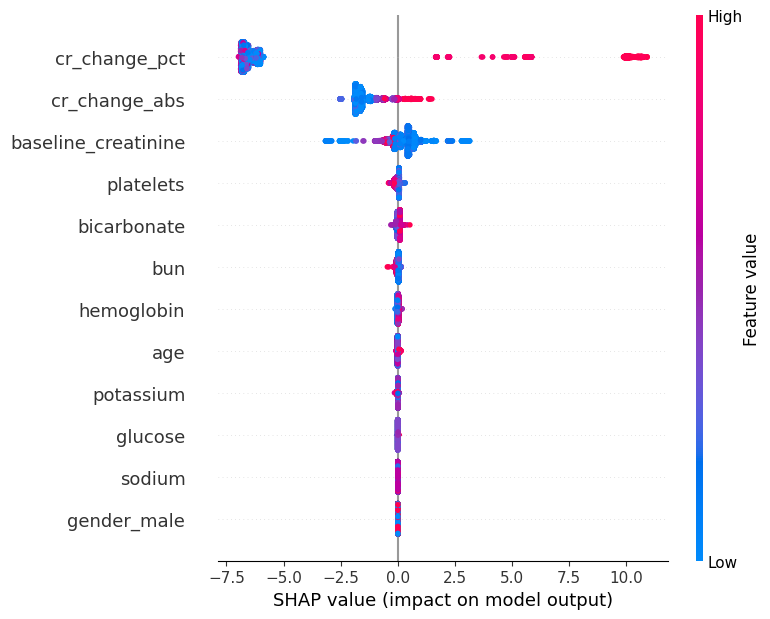

In [37]:
# summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.show()

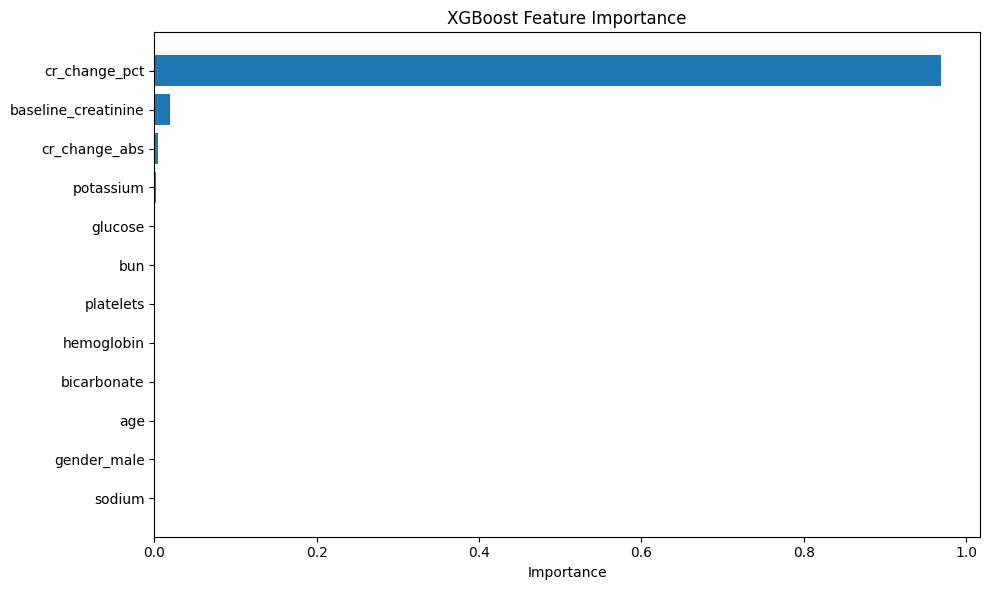


Top 5 Most Important Features:
               feature  importance
4        cr_change_pct    0.968621
2  baseline_creatinine    0.019775
3        cr_change_abs    0.004733
6            potassium    0.001593
8              glucose    0.001225


In [38]:
# feature importance from XGBoost
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

## Summary and Key Takeaways

1. **All models performed reasonably well** - even simple logistic regression got decent AUC, showing that the features (especially creatinine change) are pretty predictive.

2. **XGBoost slightly outperformed** the other individual traditional models, probably because it can capture non-linear relationships better.

3. **Ensemble approach** - Combining models through soft voting showed whether diversity in predictions helps or if the best single model is enough.

4. **LSTM results** - The LSTM looked at temporal patterns in creatinine measurements. Whether it beat the static models depends on if the trajectory matters more than just the endpoint change.

5. **Most important features** (from SHAP):
   - Creatinine change (absolute and percent) - makes sense, this is literally the definition of AKI
   - Baseline creatinine - higher baseline might indicate pre-existing kidney issues
   - BUN - another kidney function marker
   - Age - older patients might be more susceptible

6. **Clinical implications**:
   - Early creatinine monitoring is crucial
   - The rate of change matters, not just the absolute value
   - Could help identify high-risk patients for closer monitoring

### Model choice recommendations:
- **For deployment**: Ensemble or XGBoost - best performance, interpretable, don't need sequential data
- **For research**: LSTM - if you want to study temporal dynamics and have complete measurement sequences

### Limitations:
- Missing data (some patients didn't have all lab values)
- Only using 48 hours of data - longer windows might be better
- MIMIC-III is from one hospital - might not generalize everywhere
- Didn't include medications, vitals, or procedures that could affect kidney function